### Name : Ibadullah Hayat
### Reg no : B23F0001AI010
### Section : F23-AI(Green)


### Lab 05: CNN for Image Classification (CIFAR-10)

**Objective:** Build, analyze, and optimize a CNN for object classification on CIFAR-10, and compare it with a baseline MLP.

Step 1: Import Libraries & Load CIFAR-10

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set random seeds for reproducibility
np.random.seed(32)
tf.random.set_seed(32)


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [4]:
(X_train,y_train) , (X_test,y_test) = keras.datasets.cifar10.load_data()

# Class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


Step 2: Task 1.1 - Initial Dataset Exploration


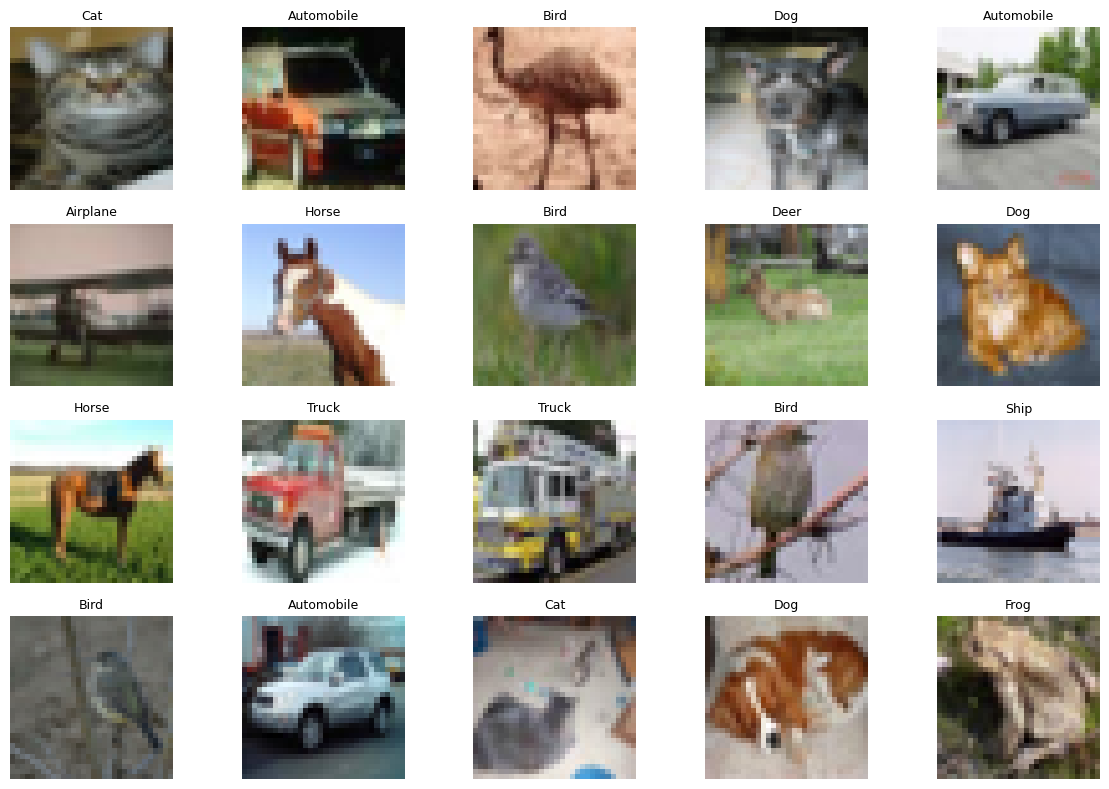


Samples per class (training):
Airplane: 5000
Automobile: 5000
Bird: 5000
Cat: 5000
Deer: 5000
Dog: 5000
Frog: 5000
Horse: 5000
Ship: 5000
Truck: 5000


In [5]:
# Display 20 random training images
plt.figure(figsize=(12, 8))
for i in range(20):
    idx = np.random.randint(0, X_train.shape[0])
    plt.subplot(4, 5, i+1)
    plt.imshow(X_train[idx])
    plt.title(class_names[y_train[idx][0]], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("\nSamples per class (training):")
for i, count in zip(unique, counts):
    print(f"{class_names[i]}: {count}")


**Visually similar classes**
- Cat vs Dog vs Bird (furry/feathered animals)
- Truck vs Automobile (vehicles)"
- Deer vs Horse (four-legged mammals)

**Insight:** Low resolution (32×32) makes fine-grained classification challenging - especially for animal classes.

Step 3: Task 2 - Baseline MLP

In [6]:
# Normalize
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Use correct loss
model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ← labels are integers!
    metrics=['accuracy']
)

# 5. Train and evaluate
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=15)
test_loss, test_acc = model.evaluate(X_test, y_test)  # ← on test set!

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.2767 - loss: 2.1312 - val_accuracy: 0.3826 - val_loss: 1.7324
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.3853 - loss: 1.7332 - val_accuracy: 0.4063 - val_loss: 1.6516
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.4137 - loss: 1.6535 - val_accuracy: 0.4249 - val_loss: 1.6035
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.4320 - loss: 1.6038 - val_accuracy: 0.4453 - val_loss: 1.5680
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.4452 - loss: 1.5695 - val_accuracy: 0.4504 - val_loss: 1.5453
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.4514 - loss: 1.5465 - val_accuracy: 0.4570 - val_loss: 1.5316
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.4579 - loss: 1.5275 - val_accuracy: 0.4630 - val_loss: 1.5145
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.4638 -

**Result**: 46% accuracy - poor due to lack of spatial feature extraction

Best Practice: Split before normalization to avoid data leakage

Step 4: Task 3 - CNN Implementation


In [7]:
# Build CNN
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train using SAME split: X_test as validation
history_cnn = cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),  # ← same as baseline
    epochs=20,
    verbose=1
)

# Evaluate on test set
test_loss_cnn, test_acc_cnn = cnn.evaluate(X_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {test_acc_cnn:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.2969 - loss: 1.8768 - val_accuracy: 0.5455 - val_loss: 1.2535
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.5246 - loss: 1.3365 - val_accuracy: 0.5795 - val_loss: 1.1499
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.5898 - loss: 1.1577 - val_accuracy: 0.6350 - val_loss: 1.0058
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6374 - loss: 1.0346 - val_accuracy: 0.6667 - val_loss: 0.9489
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6718 - loss: 0.9498 - val_accuracy: 0.6820 - val_loss: 0.9241
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6934 - loss: 0.8835 - val_accuracy: 0.6831 - val_loss: 0.9429
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7097 - loss: 0.8296 - val_accuracy: 0.6949 - val_loss: 0.9006
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7274 -

Accuracy: 71% better than baseline model.

**Note:** I haven't created separated validation set and I did the validation using the test set for validation just for checking. In real world application validation set is separated from training and test sets.


Step 5: Training Curves (CNN Only)

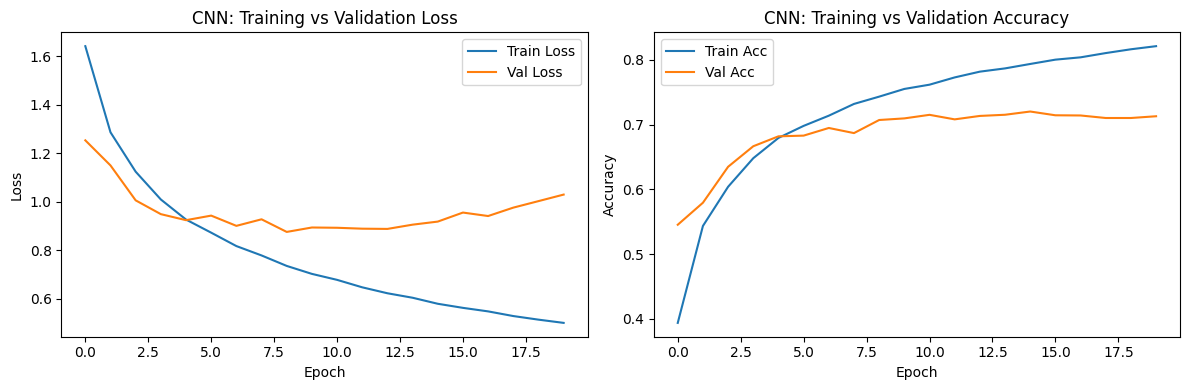

In [8]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN: Training vs Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.title('CNN: Training vs Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.tight_layout()
plt.show()

Interpretation: After epoch 8 val_loss starts rising again while train_loss keeps falling → thats when overfitting start we need to stop at the lost validation loss point

Step 6: Model Inspection (Filters & Feature Maps)

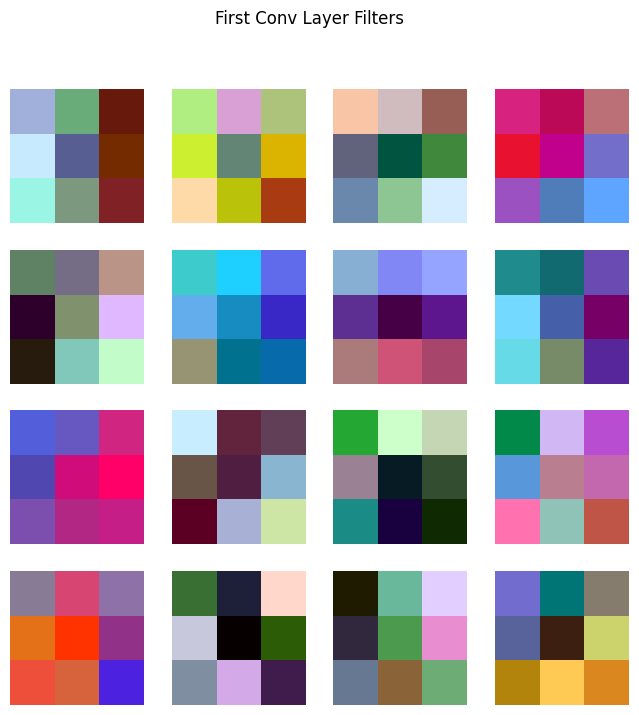

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


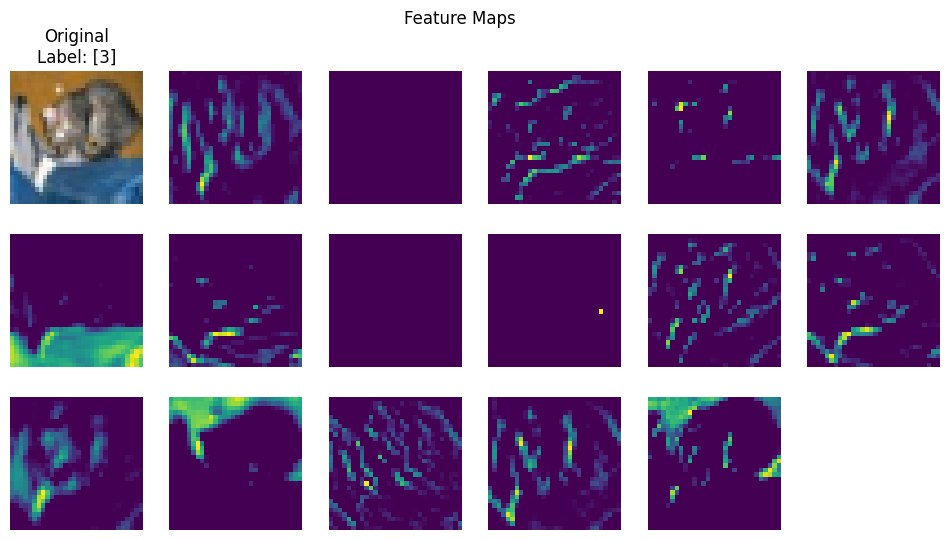

In [9]:
# Get first conv layer weights
filters, _ = cnn.layers[0].get_weights()

# Plot filters
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i in range(16):
    f = filters[:, :, :, i]
    f = (f - f.min()) / (f.max() - f.min())
    axes[i//4, i%4].imshow(f)
    axes[i//4, i%4].axis('off')
plt.suptitle('First Conv Layer Filters')
plt.show()

# Feature maps
img = X_test[0:1]  # batch of 1
feature_model = models.Model(inputs=cnn.inputs, outputs=cnn.layers[0].output)
feature_maps = feature_model.predict(img)

plt.figure(figsize=(12, 6))
plt.subplot(3, 6, 1)
plt.imshow(img[0]); plt.title(f"Original\nLabel: {y_test[0]}"); plt.axis('off')
for i in range(16):
    plt.subplot(3, 6, i+2)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle('Feature Maps')
plt.show()

Top-left grid: Strong contrast between dark (left) and light (right) → vertical edge detector

Middle row, second grid: Red/pink vs. dark → possibly color-based texture (e.g., skin vs. background)

Bottom-right grid: Warm-to-cool gradient → may detect hue transitions (e.g., red→green in vehicles)

The feature maps show **activated regions** in the first convolutional layer for a test image labeled `3` (e.g., *cat* or *deer*, depending on CIFAR-10 mapping). Bright areas (yellow/green) indicate strong responses to edges, textures, or color contrasts - confirming the network is learning meaningful low-level features. The diversity across maps suggests the model is capturing multiple visual patterns (e.g., fur texture, eye shape, background), which supports its ability to distinguish between similar classes.

Step 5: Error Analysis

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


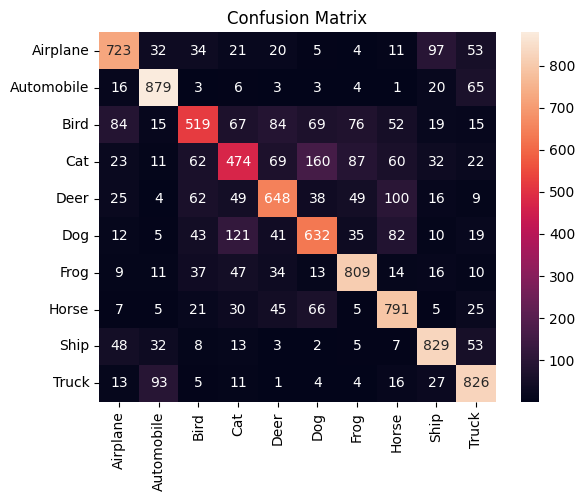

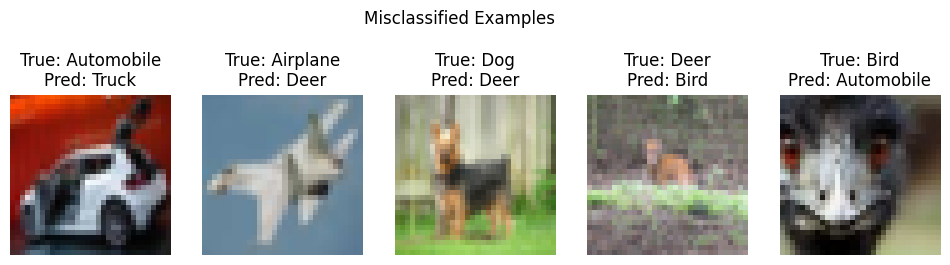

In [11]:
# Predictions
y_pred = cnn.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.show()

# Misclassified examples
misclassified = np.where(y_pred_classes != y_test.flatten())[0] # Use .flatten() to compare correctly
plt.figure(figsize=(12, 6))
for i in range(min(5, len(misclassified))):
    idx = misclassified[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {class_names[y_test[idx][0]]}\nPred: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')
plt.suptitle('Misclassified Examples')
plt.show()

**Misclassification Analysis**:

The misclassified examples reveal that errors occur primarily between visually similar classes:
Airplane → Truck (both have rigid, geometric shapes and metallic textures),

Dog → Deer and Bird → Deer (furry/feathered animals with similar color palettes and low-resolution silhouettes).

This confirms that the model struggles most when fine-grained texture or shape cues are ambiguous at 32×32 resolution - a known limitation of small CNNs on CIFAR-10.


Step 8: Optimization Challenge

In [12]:
# Smaller CNN
cnn_small = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_small.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_small.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=0)
test_loss_small, test_acc_small = cnn_small.evaluate(X_test, y_test, verbose=0)

# Compare
print(f"Original CNN Acc: {test_acc_cnn:.4f}")
print(f"Smaller CNN Acc: {test_acc_small:.4f}")
print(f"Accuracy drop: {(test_acc_cnn - test_acc_small)*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Original CNN Acc: 0.7130
Smaller CNN Acc: 0.6559
Accuracy drop: 5.71%


### Model Comparison

This shows that reducing the number of filters and dense units significantly decreases model capacity, leading to a noticeable drop in performance. While the smaller model is faster and uses less memory, the ~5.7% accuracy loss may be too high for applications requiring reliable predictions (e.g., medical or safety-critical systems).
However, in resource-constrained environments (e.g., embedded devices or warehouse robots), this trade-off might be acceptable if inference speed and memory usage are prioritized over peak accuracy.



Recommendation: For a warehouse robot sorting coarse object categories (e.g., vehicles vs animals), the original CNN (71.3% accuracy) is preferred - its performance is robust enough for real world use, and modern edge devices (like Raspberry Pi) can handle its size efficiently.